In [1]:
# import essential
import sys
from pathlib import Path

MODULE_PATH = Path("/root/capsule/src/aind_dft_ephys_analysis")

if str(MODULE_PATH) not in sys.path:
    sys.path.insert(0, str(MODULE_PATH))



In [45]:
import numpy as np
from sklearn.linear_model import LinearRegression
import xarray as xr


def _pick_psth_dataarray(
    psth_obj: xr.Dataset | xr.DataArray,
    *,
    align: str = "go_cue",
    psth_var: str | None = None,
) -> xr.DataArray:
    """
    Return a PSTH DataArray with dims (trial_dim, unit_dim, time).
    If input is a Dataset, pick the PSTH variable.
    """
    if isinstance(psth_obj, xr.DataArray):
        return psth_obj

    if not isinstance(psth_obj, xr.Dataset):
        raise TypeError(f"psth_obj must be xr.Dataset or xr.DataArray, got {type(psth_obj)}")

    if psth_var is None:
        cand = f"psth_{align}"
        if cand in psth_obj:
            psth_var = cand
        else:
            psth_vars = [k for k in psth_obj.data_vars if k.startswith("psth_")]
            if not psth_vars:
                raise KeyError("No psth_* variable found in Dataset.")
            psth_var = psth_vars[0]

    if psth_var not in psth_obj:
        raise KeyError(f"Requested psth_var='{psth_var}' not found. Available: {list(psth_obj.data_vars)}")

    return psth_obj[psth_var]


def _infer_dims(da: xr.DataArray) -> tuple[str, str, str]:
    """
    Infer (trial_dim, unit_dim, time_dim) from a PSTH DataArray.
    """
    dims = list(da.dims)
    if "time" in dims:
        time_dim = "time"
    else:
        time_dim = next((d for d in dims if "time" in d.lower()), None)
        if time_dim is None:
            raise KeyError(f"Could not find time dimension in dims={dims}")

    unit_dim = next((d for d in dims if "unit" in d.lower()), None)
    if unit_dim is None:
        raise KeyError(f"Could not find unit dimension in dims={dims}")

    trial_dim = next((d for d in dims if d not in (unit_dim, time_dim)), None)
    if trial_dim is None:
        raise KeyError(f"Could not infer trial dimension from dims={dims}")

    return trial_dim, unit_dim, time_dim


def _infer_trial_index_coord(
    ds_or_da: xr.Dataset | xr.DataArray,
    *,
    align: str,
    trial_dim: str,
) -> str | None:
    """
    Many of your saved datasets include a coord like trial_index_go_cue.
    Prefer that if present; otherwise return None.
    """
    cand = f"trial_index_{align}"

    if isinstance(ds_or_da, xr.Dataset):
        if cand in ds_or_da.coords:
            return cand
        if cand in ds_or_da.data_vars:
            return cand
    else:
        if cand in ds_or_da.coords:
            return cand

    if trial_dim in ds_or_da.coords:
        return trial_dim

    return None


def _infer_unit_id_coord(
    ds_or_da: xr.Dataset | xr.DataArray,
    *,
    unit_dim: str,
) -> str | None:
    """
    Try to find a unit identifier coordinate to return alongside the matrix.

    Preference:
      1) coord on unit_dim named "unit_id"
      2) any coord on unit_dim containing "unit" (e.g., "unit_index")
      3) fall back to the unit_dim itself if it has coords
    """
    if "unit_id" in ds_or_da.coords and unit_dim in ds_or_da.coords["unit_id"].dims:
        return "unit_id"

    # Try any coord that is 1D over unit_dim and contains "unit"
    for k, v in ds_or_da.coords.items():
        if unit_dim in v.dims and v.ndim == 1 and "unit" in k.lower():
            return k

    if unit_dim in ds_or_da.coords:
        return unit_dim

    return None


def calculate_noise_correlation(
    psth_obj: xr.Dataset | xr.DataArray,
    latent_var_values,
    *,
    trial_numbers=None,
    time_window=(-1.0, 0.0),
    align="go_cue",
    psth_var: str | None = None,
    include_trials=None,
):
    """
    Calculate noise correlation between units after regressing out confounds.

    Returns
    -------
    noise_corr_matrix : np.ndarray
        (n_units, n_units) correlation matrix.
    residuals_reshaped : np.ndarray
        (n_trials, n_units, n_timepoints) residuals after regression.
    unit_residuals_concat : np.ndarray
        (n_units, n_trials*n_timepoints) centered residuals used for corrcoef.
    unit_ids_out : np.ndarray
        (n_units,) unit identifier values aligned to matrix rows/cols.
        If no unit coordinate exists, returns np.arange(n_units).
    unit_dim_name : str
        Name of the unit dimension in the PSTH DataArray.
    """
    da = _pick_psth_dataarray(psth_obj, align=align, psth_var=psth_var)
    trial_dim, unit_dim, time_dim = _infer_dims(da)

    # Time selection
    da_win = da.sel({time_dim: slice(float(time_window[0]), float(time_window[1]))})

    # Trial id coord (for include_trials)
    trial_index_coord = _infer_trial_index_coord(psth_obj, align=align, trial_dim=trial_dim)
    if trial_index_coord is not None:
        trial_ids = (
            psth_obj[trial_index_coord].values
            if isinstance(psth_obj, xr.Dataset) and trial_index_coord in psth_obj
            else da.coords[trial_index_coord].values
        )
    else:
        trial_ids = np.arange(da_win.sizes[trial_dim])

    latent_var_values = np.asarray(latent_var_values)

    # -----------------------------
    # Filter trials by trial IDs (not by position)
    # include_trials are trial_index_{align} values
    # -----------------------------
    if include_trials is not None:
        include_trials = np.asarray(include_trials)

        id_to_pos = {int(t): i for i, t in enumerate(trial_ids)}
        idx = [id_to_pos[int(t)] for t in include_trials if int(t) in id_to_pos]

        missing = [int(t) for t in include_trials if int(t) not in id_to_pos]
        if len(missing) > 0:
            raise ValueError(
                f"{len(missing)} include_trials are not present in PSTH trial_ids. "
                f"Examples: {missing[:10]}"
            )

        da_win = da_win.isel({trial_dim: idx})
        trial_ids = np.asarray(include_trials, dtype=trial_ids.dtype)

        latent_var_values = np.asarray(latent_var_values)
        if latent_var_values.shape[0] != include_trials.shape[0]:
            raise ValueError(
                f"latent_var_values length ({latent_var_values.shape[0]}) "
                f"must match include_trials length ({include_trials.shape[0]})."
            )

        if trial_numbers is not None:
            trial_numbers = np.asarray(trial_numbers)
            if trial_numbers.shape[0] != include_trials.shape[0]:
                raise ValueError(
                    f"trial_numbers length ({trial_numbers.shape[0]}) "
                    f"must match include_trials length ({include_trials.shape[0]})."
                )

    # Dimensions
    n_trials = da_win.sizes[trial_dim]
    n_units = da_win.sizes[unit_dim]
    n_timepoints = da_win.sizes[time_dim]

    # trial_numbers
    if trial_numbers is None:
        trial_numbers = np.asarray(trial_ids) if trial_index_coord is not None else np.arange(n_trials)
    else:
        trial_numbers = np.asarray(trial_numbers)
        if trial_numbers.shape[0] != n_trials:
            raise ValueError(f"trial_numbers length ({trial_numbers.shape[0]}) must equal n_trials ({n_trials}).")

    if latent_var_values.shape[0] != n_trials:
        raise ValueError(f"latent_var_values length ({latent_var_values.shape[0]}) must equal n_trials ({n_trials}).")

    # Unit ids aligned to output matrix
    unit_id_coord = _infer_unit_id_coord(da_win, unit_dim=unit_dim)
    if unit_id_coord is not None and unit_id_coord in da_win.coords:
        unit_ids_out = np.asarray(da_win.coords[unit_id_coord].values)
    else:
        unit_ids_out = np.arange(n_units)

    # Convert to (trial, time, unit) then reshape -> (trial*time, unit)
    x = da_win.transpose(trial_dim, time_dim, unit_dim).values
    firing_rates = x.reshape(n_trials * n_timepoints, n_units)

    # Regressors repeated per timepoint
    latent_reg = np.repeat(latent_var_values, n_timepoints)
    trial_reg = np.repeat(trial_numbers, n_timepoints)

    X = np.column_stack([np.ones_like(latent_reg, dtype=float), latent_reg, trial_reg])

    residuals = np.zeros_like(firing_rates, dtype=float)

    reg = LinearRegression(fit_intercept=False)
    for unit_idx in range(n_units):
        y = firing_rates[:, unit_idx]
        reg.fit(X, y)
        residuals[:, unit_idx] = y - reg.predict(X)

    residuals_reshaped = residuals.reshape(n_trials, n_timepoints, n_units).transpose(0, 2, 1)

    # Center each unit across all concatenated samples (trial*time)
    unit_residuals_concat = residuals_reshaped.reshape(n_trials * n_timepoints, n_units).T
    unit_residuals_concat = unit_residuals_concat - unit_residuals_concat.mean(axis=1, keepdims=True)

    noise_corr_matrix = np.corrcoef(unit_residuals_concat)

    return noise_corr_matrix, residuals_reshaped, unit_residuals_concat, unit_ids_out, unit_dim


In [206]:
import numpy as np
import xarray as xr

# -----------------------------
# Session configuration
# -----------------------------


#session_name = 'ecephys_769884_2025-01-16_18-33-11_sorted_2025-04-24_19-24-23'
session_name = 'ecephys_776293_2025-02-14_15-19-17_sorted_2025-02-28_21-37-07'
#session_name = 'ecephys_776293_2025-02-18_12-51-36_sorted_2025-03-30_05-50-33'
#session_name = 'ecephys_776293_2025-02-19_14-01-07_sorted_2025-03-30_08-55-28'
#session_name = 'ecephys_780618_2025-04-16_15-54-21_sorted_2025-04-18_12-51-23'
#session_name = 'ecephys_781471_2025-03-31_14-33-03_sorted_2025-04-01_15-50-16'
#session_name = "ecephys_764769_2024-12-11_18-21-49_sorted_2024-12-13_10-04-48"
#session_name = 'ecephys_776293_2025-02-18_12-51-36_sorted_2025-03-30_05-50-33'
#session_name ='ecephys_769884_2025-01-15_16-12-59_sorted_2025-04-24_17-11-57'

binsize = "0.1"
align = "go_cue"
time_window0 = (-4, 0)
latent_var = "ForagingCompareThreshold-value-1"

# -----------------------------
# Load data
# -----------------------------
# Assumptions:
# - load_zarr(...) returns an xr.Dataset (preferred) or xr.DataArray
# - smart_read_csv(...) returns a pandas DataFrame where:
#   - df["response_trials"][0] is a list/array of trial indices (trial_index_go_cue values)
#   - df[latent_var][0] is a list/array of latent values aligned to response_trials
psth_obj = load_zarr(f"/root/capsule/scratch/psth_results/{session_name}_{binsize}s.zarr")
df = smart_read_csv(f"/root/capsule/scratch/behavior_summary/behavior_summary-{session_name}.csv")

# If psth_obj is a Dataset, set psth_var explicitly (recommended)
psth_var = f"psth_{align}" if isinstance(psth_obj, xr.Dataset) else None

# Trials to include (these should be trial_index_go_cue values)
include_trials = np.asarray(df["response_trials"][0], dtype=int)

# Latent values aligned to include_trials
latent_values = np.asarray(df[latent_var][0], dtype=float)

# Use the same trial ids for trial_numbers regressor (common choice)
trial_numbers = include_trials.copy()

if latent_values.shape[0] != include_trials.shape[0]:
    raise ValueError(
        f"latent_values length ({latent_values.shape[0]}) must match include_trials length ({include_trials.shape[0]}). "
        "Your df[latent_var][0] must be aligned to df['response_trials'][0]."
    )

print(f"Trials to include: {include_trials.size}")
print(f"Latent range: {latent_values.min():.4f} to {latent_values.max():.4f}")

# -----------------------------
# Compute noise correlation
# -----------------------------
noise_corr_all, residuals_all, unit_resid_all, unit_ids_out, unit_dim = calculate_noise_correlation(
    psth_obj=psth_obj,
    psth_var=psth_var,
    align=align,
    latent_var_values=latent_values,
    trial_numbers=trial_numbers,
    time_window=time_window0,
    include_trials=include_trials,
)

print("Matrix shape:", noise_corr_all.shape)
print("Unit dim:", unit_dim)
print("First 10 unit ids:", unit_ids_out[:10])

print(f"Noise correlation matrix shape: {noise_corr_all.shape}")

# Mean abs off-diagonal correlation
offdiag = noise_corr_all[~np.eye(noise_corr_all.shape[0], dtype=bool)]
print(f"Mean |corr| (off-diagonal): {np.mean(np.abs(offdiag)):.4f}")

# -----------------------------
# Save
# -----------------------------
out_path = (
    f"/root/capsule/scratch/long_time_scale_correlation/"
    f"noise_corr_all_{session_name}_{latent_var}_timewindow_{time_window0[0]}_{time_window0[1]}.npy"
)
np.save(out_path, noise_corr_all)
print(f"Saved: {out_path}")


Trials to include: 638
Latent range: -0.2137 to 0.9741
Matrix shape: (800, 800)
Unit dim: unit
First 10 unit ids: [ 1  3  4  7  8  9 12 13 14 18]
Noise correlation matrix shape: (800, 800)
Mean |corr| (off-diagonal): 0.0194
Saved: /root/capsule/scratch/long_time_scale_correlation/noise_corr_all_ecephys_776293_2025-02-14_15-19-17_sorted_2025-02-28_21-37-07_ForagingCompareThreshold-value-1_timewindow_-4_0.npy


In [207]:
from __future__ import annotations

# ------------------------------
# Project imports
# ------------------------------
from general_utils import load_df_with_psth_csv
from behavior_qc_visualization import load_behavior_model_summary_csv
from behavior_qc_metrics_summary import (
    append_model_criteria_result,
    append_summary_to_df_by_session,
)
from ephys_utils import summarize_units_by_region_and_session

from check_monotonic import (
    load_and_combine_monotonic_unit_dfs,
    summarize_significant_and_monotonic_fractions,
)

# ------------------------------
# Load unit locations
# ------------------------------
df_unitloc = load_df_with_psth_csv("/root/capsule/scratch/unit_locations_by_session.csv")

# ------------------------------
# Load model summary + append criteria
# ------------------------------
summary = load_behavior_model_summary_csv(
    "/root/capsule/scratch/behavior_model_summary_ephys_sessions.csv"
)
summary = append_model_criteria_result(summary)

# ------------------------------
# Append QC summary columns onto unit-locations df
# ------------------------------
df_with_summary = append_summary_to_df_by_session(
    df_unitloc,
    summary,
    df_session_col="session_name",
    summary_session_col="session_name",
    summary_cols=[
        "QLearning_L1F1_CK1_softmax_pass_all_criteria",
    ],
    prefix="summary_",
)

# ------------------------------
# Summarize units by region and session
# ------------------------------
session_region_summary = summarize_units_by_region_and_session(df_with_summary)
session_region_summary

# ------------------------------
# Load monotonic outputs
# ------------------------------
combined_df = load_and_combine_monotonic_unit_dfs(
    "/root/capsule/scratch/monotonic_outputs_n_4/ForagingCompareThreshold-value-1/win_m1__0",
    pattern="*.csv",
    recursive=True,
    add_source_file=True,
)
print("combined_df shape (before filtering inside function):", combined_df.shape)

# ------------------------------
# Summarize significant + monotonic fractions (with session QC filtering)
# ------------------------------
out = summarize_significant_and_monotonic_fractions(
    combined_df,
    alpha=0.05,
    p_col="spearman_p",
    monotonic_col="is_monotonic",
    include_overall=True,
    summary=summary,
    # criteria_col="QLearning_L2F1_softmax_pass_all_criteria",
)


[LOAD] Reading CSV: /root/capsule/scratch/unit_locations_by_session.csv
[LOAD] Restoring 0 array columns...
[LOAD] Done.


/root/capsule/src/aind_dft_ephys_analysis/ephys_utils.py:783: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[pass_col] = df[pass_col].fillna(False).astype(bool)


combined_df shape (before filtering inside function): (25055, 90)


In [208]:
import pandas as pd

# Use combined_df directly
df = combined_df.copy()

# --- filter brain_region to SI or MA ---
df = df[df["brain_region"].isin(["SI", "MA"])].copy()


#df = df[df["brain_region"].isin(["MD"])].copy()
# --- keep only finite rho ---
df = df[df["spearman_rho"].notna()].copy()

session_summary = []

for session, sub in df.groupby("session_name", sort=False):

    # All positive / negative
    pos = sub[sub["spearman_rho"] > 0]
    neg = sub[sub["spearman_rho"] < 0]

    # Significant positive / negative
    pos_sig = sub[(sub["spearman_rho"] > 0) & (sub["spearman_p"] < 0.05)]
    neg_sig = sub[(sub["spearman_rho"] < 0) & (sub["spearman_p"] < 0.05)]

    session_summary.append({
        "session_name": session,

        # total
        "n_all": int(len(sub)),

        # raw counts
        "n_positive": int(len(pos)),
        "n_negative": int(len(neg)),

        # significant counts
        "n_positive_significant": int(len(pos_sig)),
        "n_negative_significant": int(len(neg_sig)),

        # unit lists
        "unit_index_all": sub["unit_index"].tolist(),
        "positive_unit_index": pos["unit_index"].tolist(),
        "negative_unit_index": neg["unit_index"].tolist(),
        "positive_unit_index_significant": pos_sig["unit_index"].tolist(),
        "negative_unit_index_significant": neg_sig["unit_index"].tolist(),
    })

session_summary_df = pd.DataFrame(session_summary)

session_summary_df


,session_name,n_all,n_positive,n_negative,n_positive_significant,n_negative_significant,unit_index_all,positive_unit_index,negative_unit_index,positive_unit_index_significant,negative_unit_index_significant
0,ecephys_764790_2024-12-19_16-11-34_sorted_2025...,73,32,41,12,11,"[287, 236, 265, 281, 441, 263, 270, 272, 458, ...","[272, 458, 479, 436, 276, 273, 293, 262, 489, ...","[287, 236, 265, 281, 441, 263, 270, 306, 310, ...","[272, 458, 479, 436, 276, 273, 293, 262, 489, ...","[281, 441, 263, 270, 476, 277, 449, 264, 312, ..."
1,ecephys_769884_2025-01-16_18-33-11_sorted_2025...,25,18,7,11,5,"[288, 191, 445, 454, 197, 301, 294, 448, 209, ...","[445, 454, 197, 301, 294, 448, 209, 299, 142, ...","[288, 191, 201, 449, 500, 439, 292]","[445, 454, 197, 301, 294, 448, 209, 299, 142, ...","[288, 191, 500, 439, 292]"
2,ecephys_776293_2025-02-14_15-19-17_sorted_2025...,221,73,148,32,70,"[1390, 1661, 1576, 1859, 1568, 1572, 1644, 184...","[1877, 1840, 2036, 1836, 1698, 2042, 1671, 189...","[1390, 1661, 1576, 1859, 1568, 1572, 1644, 184...","[1877, 1840, 2036, 1836, 1698, 2042, 1671, 189...","[1390, 1644, 1849, 1584, 1396, 1850, 1439, 141..."
3,ecephys_776293_2025-02-18_12-51-36_sorted_2025...,123,69,54,30,15,"[1908, 1858, 1820, 1914, 2124, 1901, 1918, 198...","[1787, 1956, 1984, 2162, 1813, 2094, 1974, 210...","[1908, 1858, 1820, 1914, 2124, 1901, 1918, 198...","[1787, 1956, 1984, 2162, 1813, 2094, 1974, 210...","[1820, 1914, 2124, 1918, 1983, 1836, 1815, 185..."
4,ecephys_776293_2025-02-19_14-01-07_sorted_2025...,8,4,4,1,3,"[2397, 2400, 2396, 2403, 2398, 2401, 2399, 2402]","[2400, 2396, 2403, 2398]","[2397, 2401, 2399, 2402]",[2400],"[2397, 2399, 2402]"
5,ecephys_780618_2025-04-15_13-30-58_sorted_2025...,173,89,84,61,54,"[1227, 1535, 1917, 1418, 1256, 2085, 1599, 198...","[1373, 1965, 1300, 1731, 1578, 1568, 1954, 202...","[1227, 1535, 1917, 1418, 1256, 2085, 1599, 198...","[1373, 1965, 1300, 1731, 1578, 1568, 1954, 202...","[1535, 1917, 1418, 1256, 2085, 1599, 1985, 128..."
6,ecephys_780618_2025-04-16_15-54-21_sorted_2025...,60,27,33,7,10,"[1892, 2188, 1898, 1910, 2002, 2168, 2194, 219...","[2193, 1919, 1904, 1900, 2192, 2170, 2176, 218...","[1892, 2188, 1898, 1910, 2002, 2168, 2194, 220...","[2193, 1919, 1900, 2170, 2176, 2187, 2004]","[1910, 2002, 2168, 2194, 1893, 2195, 2202, 192..."
7,ecephys_781471_2025-03-31_14-33-03_sorted_2025...,24,5,19,3,13,"[1835, 1850, 1857, 1858, 1855, 1854, 1819, 182...","[1834, 1818, 1853, 1833, 1856]","[1835, 1850, 1857, 1858, 1855, 1854, 1819, 182...","[1834, 1818, 1853]","[1850, 1857, 1858, 1855, 1854, 1819, 1827, 184..."


In [169]:
import pandas as pd
import numpy as np

# Extract the dataframe
df = out['by_brain_region_group']['[SI,MA]']['significant_monotonic_df']

# Make sure spearman_rho is numeric
df = df[df['spearman_rho'].notna()].copy()

# Group by session_name
session_summary = []

for session, sub in df.groupby('session_name'):
    
    # Positive units
    pos = sub[sub['spearman_rho'] > 0]
    neg = sub[sub['spearman_rho'] < 0]
    
    session_summary.append({
        'session_name': session,
        'n_positive': len(pos),
        'n_negative': len(neg),
        'positive_unit_index': pos['unit_index'].tolist(),
        'negative_unit_index': neg['unit_index'].tolist(),
    })

session_summary_df = pd.DataFrame(session_summary)

session_summary_df


,session_name,n_positive,n_negative,positive_unit_index,negative_unit_index
0,ecephys_769884_2025-01-16_18-33-11_sorted_2025...,3,2,"[445, 454, 197]","[288, 191]"
1,ecephys_776293_2025-02-14_15-19-17_sorted_2025...,9,31,"[1877, 1840, 2036, 1836, 1698, 2042, 1671, 189...","[1390, 1644, 1849, 1584, 1396, 1850, 1439, 141..."
2,ecephys_776293_2025-02-18_12-51-36_sorted_2025...,13,7,"[1787, 1956, 1984, 2162, 1813, 2094, 1974, 210...","[1820, 1914, 2124, 1918, 1983, 1836, 1815]"
3,ecephys_776293_2025-02-19_14-01-07_sorted_2025...,1,1,[2400],[2397]
4,ecephys_780618_2025-04-16_15-54-21_sorted_2025...,3,4,"[2193, 1919, 1900]","[1910, 2002, 2168, 2194]"
5,ecephys_781471_2025-03-31_14-33-03_sorted_2025...,0,8,[],"[1850, 1857, 1858, 1855, 1854, 1819, 1827, 1848]"


In [198]:
session_summary_df['session_name'][7]

'ecephys_769884_2025-01-15_16-12-59_sorted_2025-04-24_17-11-57'

In [160]:
for i in range(6):
    print(session_summary_df['session_name'][i])

ecephys_764769_2024-12-11_18-21-49_sorted_2024-12-13_10-04-48
ecephys_764790_2024-12-17_16-57-52_sorted_2024-12-20_18-46-41
ecephys_764790_2024-12-18_12-14-41_sorted_2024-12-21_23-37-20
ecephys_764791_2025-01-14_12-04-05_sorted_2025-04-24_18-24-08
ecephys_769884_2025-01-14_14-53-24_sorted_2025-01-24_14-20-13
ecephys_769884_2025-01-15_16-12-59_sorted_2025-04-24_17-11-57


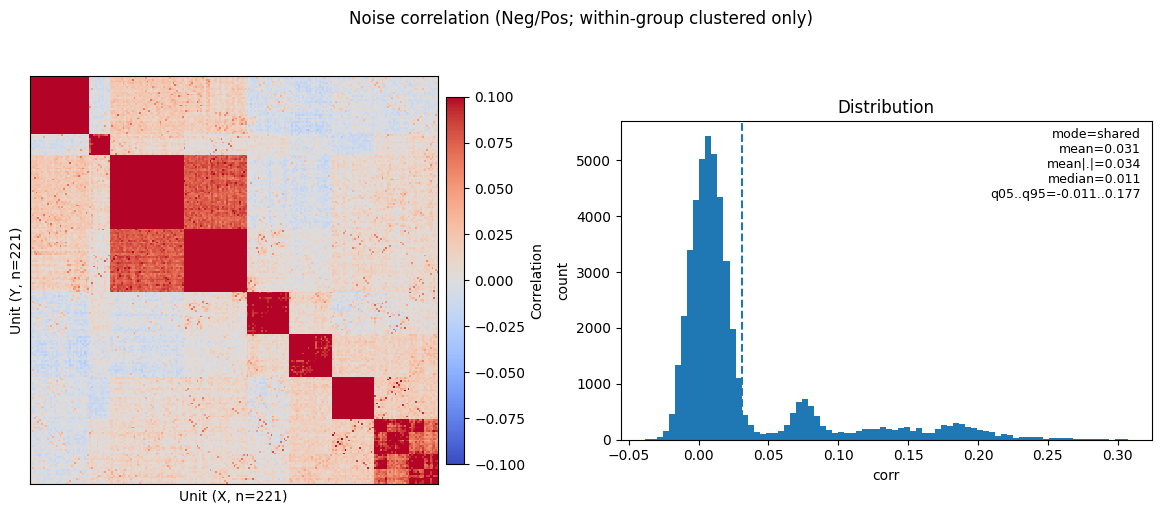

In [218]:
import ast
import matplotlib.pyplot as plt


# -----------------------------
# 2) Plot on ONE figure:
#    - cluster within neg
#    - cluster within pos
#    - no cross-group clustering
# -----------------------------
out = plot_noise_correlation_clustered(
    noise_corr_all,
    unit_ids=unit_ids_out,                 # full ordering for noise_corr_all
    include_unit_ids=session_summary_df['unit_index_all'][2],
    vlim=0.1,
    show_distribution=True,
    cluster_axis_mode="shared",
    title="Noise correlation (Neg/Pos; within-group clustered only)",
)

plt.show()

# Ordered IDs exactly as shown on axes:
unit_ids_x = out["unit_ids_x"]
unit_ids_y = out["unit_ids_y"]


In [212]:
session_name_target = session_name 

df_filtered = combined_df[
    (combined_df["session_name"] == session_name_target) &
    (combined_df["spearman_p"] < 0.05) &
    (combined_df["brain_region"].isin(["SI", "MA"]))
    #(combined_df["brain_region"].isin(["MD"]))
]

# Positive significant units
pos_unit_index = df_filtered.loc[
    df_filtered["spearman_rho"] > 0,
    "unit_index"
].unique()

# Negative significant units
neg_unit_index = df_filtered.loc[
    df_filtered["spearman_rho"] < 0,
    "unit_index"
].unique()

print("Positive unit_index:")
print(pos_unit_index)

print("\nNegative unit_index:")
print(neg_unit_index)


Positive unit_index:
[1877 1840 2036 1836 1698 2042 1671 1896 1858 1893 2017 1579 1846 1892
 1811 2005 1449 1660 1628 1448 2038 1822 1673 1667 1800 1457 1620 1596
 1614 1640 1475 2010]

Negative unit_index:
[1390 1644 1849 1584 1396 1850 1439 1417 1852 1480 1429 1397 1678 1611
 1833 1690 1431 1419 1492 1460 1490 1401 1593 1453 1432 2031 1452 2035
 1683 1443 1415 1400 1884 1486 1612 1477 1428 2000 1458 1903 1645 1688
 1476 1789 1636 1578 1878 1895 2024 1588 1438 1474 1869 1472 1837 1575
 1489 1437 1816 2039 1819 1687 1402 1478 1631 1676 1470 1835 1409 1467]


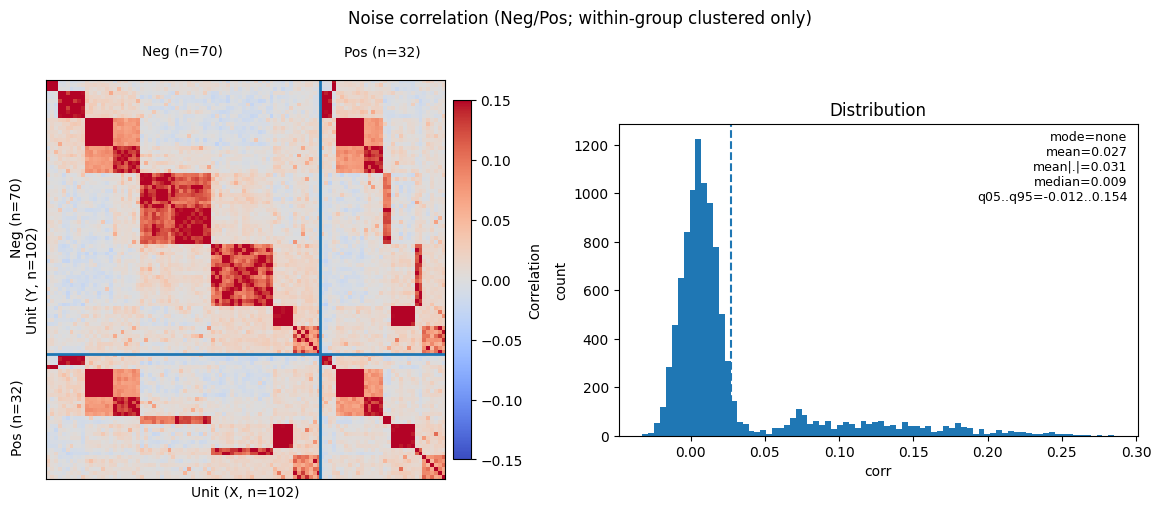

In [213]:
import ast
import matplotlib.pyplot as plt

# -----------------------------
# 1) Get neg/pos unit lists for a specific session (row index = 1)
# -----------------------------
neg_ids = session_summary_df["negative_unit_index"].iloc[2]
pos_ids = session_summary_df["positive_unit_index"].iloc[2]


pos_ids=pos_unit_index
neg_ids=neg_unit_index
# If these came from CSV, they may be strings like "[1, 2, 3]"
if isinstance(neg_ids, str):
    neg_ids = ast.literal_eval(neg_ids)
if isinstance(pos_ids, str):
    pos_ids = ast.literal_eval(pos_ids)

neg_ids = list(neg_ids)
pos_ids = list(pos_ids)

# -----------------------------
# 2) Plot on ONE figure:
#    - cluster within neg
#    - cluster within pos
#    - no cross-group clustering
# -----------------------------
out = plot_noise_correlation_clustered(
    noise_corr_all,
    unit_ids=unit_ids_out,                 # full ordering for noise_corr_all
    within_group_ids=[neg_ids, pos_ids],   # <-- key line
    within_group_mode="keep_group_order",  # keep Neg then Pos
    group_labels=["Neg", "Pos"],           # optional labels
    vlim=0.15,
    show_distribution=True,
    title="Noise correlation (Neg/Pos; within-group clustered only)",
)

plt.show()

# Ordered IDs exactly as shown on axes:
unit_ids_x = out["unit_ids_x"]
unit_ids_y = out["unit_ids_y"]


/tmp/ipykernel_2171968/4137552774.py:102: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=labels, showfliers=False)


{'fig': <Figure size 600x500 with 1 Axes>,
 'ax': <Axes: title={'center': 'Within vs Cross-group correlation'}, ylabel='Noise correlation'>,
 'within_values': [array([-0.00389349,  0.01414744, -0.01202094, ...,  0.24311361,
          0.01552233,  0.00642042], shape=(4830,)),
  array([ 7.78154850e-03,  1.08809966e-02,  3.44281605e-03,  3.79337811e-03,
         -4.16677905e-03,  7.92819892e-02,  1.24034859e-01,  1.46768225e-01,
          1.38515170e-01,  7.60454294e-03,  5.32538099e-02,  7.51098184e-03,
          1.17747748e-01,  7.61533698e-03,  1.21703644e-02,  4.13749984e-03,
          6.24699109e-02,  7.84126270e-02,  1.07498063e-02,  9.19980024e-03,
          8.49353190e-04,  8.08198450e-02,  7.44979673e-02,  8.73627289e-03,
         -9.07334108e-03,  7.36984625e-02,  2.03321079e-02,  3.39478057e-03,
          6.77302474e-02, -1.85572975e-03, -3.64522439e-03,  7.78154850e-03,
          1.04759226e-01,  9.10701658e-02,  1.54245691e-02,  1.27193077e-02,
          1.96528927e-02,  6.33

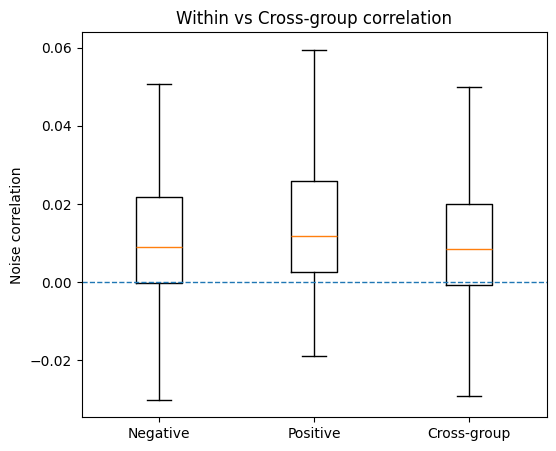

In [214]:
plot_within_vs_cross_group_boxplot(
    noise_corr=noise_corr_all,
    unit_ids=unit_ids_out,
    within_group_ids=[neg_ids, pos_ids],
    group_labels=["Negative", "Positive"],
)


In [142]:
from __future__ import annotations

from pathlib import Path
from typing import Any, Dict, Optional, Sequence, Tuple, Union, Literal, List

import numpy as np
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import linkage, leaves_list
from scipy.spatial.distance import pdist


def _compute_cluster_order_from_matrix(
    M: np.ndarray,
    *,
    method: str = "average",
    metric: str = "correlation",
) -> np.ndarray:
    """
    Compute a hierarchical clustering leaf order from a square matrix.

    We treat each row as a feature vector and cluster rows using pdist(rows, metric).
    """
    X = np.asarray(M, dtype=float)
    if X.ndim != 2 or X.shape[0] != X.shape[1]:
        raise ValueError(f"M must be square, got shape={X.shape}")

    X = X.copy()
    # Avoid trivial self-identity dominating the pattern for correlation-like matrices
    np.fill_diagonal(X, 0.0)
    X[~np.isfinite(X)] = 0.0

    D = pdist(X, metric=metric)
    Z = linkage(D, method=method)
    order = leaves_list(Z).astype(int)
    if order.size != X.shape[0]:
        raise RuntimeError("Clustering produced invalid leaf order.")
    return order


def plot_noise_correlation_clustered(
    noise_corr: np.ndarray,
    *,
    # You can pass either one shared list (unit_ids) or separate x/y lists
    unit_ids: Optional[Sequence[Union[int, str]]] = None,
    unit_ids_x: Optional[Sequence[Union[int, str]]] = None,
    unit_ids_y: Optional[Sequence[Union[int, str]]] = None,
    # Optionally restrict plot to only these unit ids (must be present in unit_ids/unit_ids_x)
    include_unit_ids: Optional[Sequence[Union[int, str]]] = None,
    # NEW: group-aware clustering (within-group clustering only)
    within_group_ids: Optional[Sequence[Sequence[Union[int, str]]]] = None,
    within_group_mode: Literal["keep_group_order", "cluster_groups"] = "keep_group_order",
    draw_group_dividers: bool = True,
    group_divider_linewidth: float = 2.0,
    group_labels: Optional[Sequence[str]] = None,
    group_label_fontsize: int = 10,
    group_label_pad: int = 6,
    cluster_axis_mode: Literal["shared", "separate", "none"] = "shared",
    title: str = "Noise correlation",
    subtitle: Optional[str] = None,
    figsize: Tuple[float, float] = (11.5, 5.2),
    cmap: str = "coolwarm",
    vlim: Optional[float] = None,
    vmin: Optional[float] = None,
    vmax: Optional[float] = None,
    show_colorbar: bool = True,
    show_distribution: bool = True,
    # clustering params
    cluster_method: str = "average",
    cluster_metric: str = "correlation",
    # ticks
    show_unit_ticks: bool = False,
    tick_step: Optional[int] = None,
    max_tick_labels: int = 40,
    # colorbar tuning
    colorbar_shrink: float = 0.85,
    colorbar_fraction: float = 0.045,
    colorbar_pad: float = 0.02,
    # histogram tuning (not tied to vmin/vmax)
    hist_bins: int = 80,
    hist_box_aspect: float = 0.6,  # < 1 makes it flatter (less tall)
    # save
    save_path: Optional[Union[str, Path]] = None,
    dpi: int = 200,
) -> Dict[str, Any]:
    """
    Plot a (typically symmetric) noise correlation matrix with hierarchical clustering.

    Standard modes:
      - cluster_axis_mode="shared": one order applied to both axes (recommended for symmetric matrices)
      - cluster_axis_mode="separate": cluster rows and cols independently (useful for non-symmetric matrices)
      - cluster_axis_mode="none": no clustering, identity order

    Subsetting:
      - include_unit_ids: subset to a provided set/list of unit IDs (in that order) before clustering/plotting.

    Group-aware within-group clustering (NO cross-group mixing):
      - within_group_ids: list of groups, e.g. [neg_ids, pos_ids]
        Each group is clustered internally; groups are concatenated (kept together).
      - within_group_mode:
          * "keep_group_order": keep groups in the given order
          * "cluster_groups": optionally cluster groups by their group-mean correlation profiles
      - When within_group_ids is provided, it takes precedence over cluster_axis_mode and forces a grouped order
        with within-group clustering only.

    Returns orders and unit_ids for both axes so you can map any pixel (i,j) back.
    """
    C_full = np.asarray(noise_corr, dtype=float)
    if C_full.ndim != 2 or C_full.shape[0] != C_full.shape[1]:
        raise ValueError(f"noise_corr must be square 2D array, got shape={C_full.shape}")
    n_full = C_full.shape[0]

    # Resolve unit ids
    if unit_ids is not None:
        if unit_ids_x is not None or unit_ids_y is not None:
            raise ValueError("Pass either unit_ids OR (unit_ids_x/unit_ids_y), not both.")
        unit_ids_x = unit_ids
        unit_ids_y = unit_ids

    if unit_ids_x is not None:
        unit_ids_x = list(unit_ids_x)
        if len(unit_ids_x) != n_full:
            raise ValueError(f"unit_ids_x length ({len(unit_ids_x)}) must match n_units ({n_full}).")
    if unit_ids_y is not None:
        unit_ids_y = list(unit_ids_y)
        if len(unit_ids_y) != n_full:
            raise ValueError(f"unit_ids_y length ({len(unit_ids_y)}) must match n_units ({n_full}).")

    # Helper: subset matrix+ids to a list of ids (order preserved)
    def _subset_by_ids(
        C_in: np.ndarray,
        ids_in: Optional[List[Union[int, str]]],
        ids_keep: Sequence[Union[int, str]],
    ) -> Tuple[np.ndarray, Optional[List[Union[int, str]]], np.ndarray]:
        if ids_in is None:
            raise ValueError("Subsetting by IDs requires unit_ids (or unit_ids_x) to be provided.")
        ids_keep = list(ids_keep)
        id_to_index = {uid: i for i, uid in enumerate(ids_in)}
        missing = [uid for uid in ids_keep if uid not in id_to_index]
        if missing:
            raise ValueError(f"These unit IDs were not found in unit_ids: {missing}")
        idx = np.array([id_to_index[uid] for uid in ids_keep], dtype=int)
        C_out = C_in[np.ix_(idx, idx)]
        ids_out = [ids_in[i] for i in idx]
        return C_out, ids_out, idx

    # -------------------------------------------------
    # Group-aware within-group clustering (no cross-group mixing)
    # -------------------------------------------------
    group_boundaries: Optional[List[int]] = None
    group_names: Optional[List[str]] = None

    subset_indices: Optional[np.ndarray] = None

    if within_group_ids is not None:
        if unit_ids_x is None:
            raise ValueError("within_group_ids requires unit_ids (or unit_ids_x) to be provided.")
        if include_unit_ids is not None:
            raise ValueError("Pass either within_group_ids OR include_unit_ids, not both.")

        groups = [list(g) for g in within_group_ids]
        if len(groups) == 0:
            raise ValueError("within_group_ids must contain at least one group.")
        if any(len(g) == 0 for g in groups):
            raise ValueError("within_group_ids contains an empty group; each group must have >= 1 id.")

        # Optional: label each group (will append n automatically)
        if group_labels is not None:
            base_names = [str(x) for x in group_labels]
            if len(base_names) != len(groups):
                raise ValueError("group_labels length must match within_group_ids length.")
        else:
            base_names = [f"Group {i+1}" for i in range(len(groups))]

        # Append number of units to labels
        group_names = [
            f"{name} (n={len(g)})"
            for name, g in zip(base_names, groups)
        ]

        # Build per-group clustered order, then concatenate
        id_to_index_full = {uid: i for i, uid in enumerate(unit_ids_x)}

        # Validate all ids exist & compute original indices
        group_indices_full: List[np.ndarray] = []
        for g in groups:
            missing = [uid for uid in g if uid not in id_to_index_full]
            if missing:
                raise ValueError(f"Group contains ids not found in unit_ids: {missing}")
            group_indices_full.append(np.array([id_to_index_full[uid] for uid in g], dtype=int))

        # Decide group order (either as given, or cluster groups by group-mean profiles)
        group_order = list(range(len(groups)))

        if within_group_mode == "cluster_groups" and len(groups) >= 2:
            # Build a small group-group similarity matrix based on mean correlations between groups.
            # Then cluster that group-level matrix to order groups.
            G = len(groups)
            GG = np.zeros((G, G), dtype=float)
            for i in range(G):
                for j in range(G):
                    block = C_full[np.ix_(group_indices_full[i], group_indices_full[j])]
                    finite = block[np.isfinite(block)]
                    GG[i, j] = float(np.nanmean(finite)) if finite.size else 0.0
            # For stability, ensure square and finite
            GG[~np.isfinite(GG)] = 0.0
            np.fill_diagonal(GG, 0.0)
            group_order = _compute_cluster_order_from_matrix(GG, method=cluster_method, metric=cluster_metric).tolist()
        elif within_group_mode != "keep_group_order":
            raise ValueError(f"Unknown within_group_mode='{within_group_mode}'.")

        # Reorder groups accordingly
        groups = [groups[i] for i in group_order]
        group_indices_full = [group_indices_full[i] for i in group_order]
        group_names = [group_names[i] for i in group_order]

        # Within-group clustering
        ordered_ids: List[Union[int, str]] = []
        ordered_full_indices: List[int] = []
        boundaries: List[int] = []
        running = 0

        for g_ids, g_idx_full in zip(groups, group_indices_full):
            Cg = C_full[np.ix_(g_idx_full, g_idx_full)]
            if Cg.shape[0] >= 3:
                o = _compute_cluster_order_from_matrix(Cg, method=cluster_method, metric=cluster_metric)
            else:
                o = np.arange(Cg.shape[0], dtype=int)

            g_ids_ord = [g_ids[i] for i in o]
            g_idx_full_ord = [int(g_idx_full[i]) for i in o]

            ordered_ids.extend(g_ids_ord)
            ordered_full_indices.extend(g_idx_full_ord)

            running += len(g_ids_ord)
            boundaries.append(running)

        # Subset matrix to these ids, in this exact grouped order
        subset_indices = np.asarray(ordered_full_indices, dtype=int)
        C = C_full[np.ix_(subset_indices, subset_indices)]
        unit_ids_x = ordered_ids
        unit_ids_y = ordered_ids if unit_ids_y is not None else None

        group_boundaries = boundaries[:-1]  # internal boundaries only (exclude final end)
        group_names = group_names

        # Since we've already built the final order, force no extra clustering
        cluster_axis_mode_effective: Literal["none"] = "none"

    else:
        # -------------------------------------------------
        # Optional: filter to only selected unit IDs
        # -------------------------------------------------
        if include_unit_ids is not None:
            C, unit_ids_x, subset_indices = _subset_by_ids(C_full, unit_ids_x, include_unit_ids)
            unit_ids_y = [unit_ids_y[i] for i in subset_indices] if unit_ids_y is not None else None
        else:
            C = C_full
            subset_indices = None

        cluster_axis_mode_effective = cluster_axis_mode

    n = C.shape[0]

    # Decide clustering orders (standard, unless grouped mode forced "none")
    if cluster_axis_mode_effective == "none" or n < 3:
        order_x = np.arange(n, dtype=int)
        order_y = np.arange(n, dtype=int)
    elif cluster_axis_mode_effective == "shared":
        order = _compute_cluster_order_from_matrix(C, method=cluster_method, metric=cluster_metric)
        order_x = order
        order_y = order
    elif cluster_axis_mode_effective == "separate":
        order_x = _compute_cluster_order_from_matrix(C, method=cluster_method, metric=cluster_metric)
        order_y = _compute_cluster_order_from_matrix(C.T, method=cluster_method, metric=cluster_metric)
    else:
        raise ValueError(f"Unknown cluster_axis_mode='{cluster_axis_mode_effective}'.")

    C_ord = C[np.ix_(order_y, order_x)]  # note: x is columns, y is rows
    unit_ids_x_ord = [unit_ids_x[i] for i in order_x] if unit_ids_x is not None else None
    unit_ids_y_ord = [unit_ids_y[i] for i in order_y] if unit_ids_y is not None else None

    # Off-diagonal stats (only meaningful if matrix is symmetric and shared order)
    offdiag = C_ord[~np.eye(n, dtype=bool)] if C_ord.shape[0] == C_ord.shape[1] else C_ord.ravel()
    offdiag = offdiag[np.isfinite(offdiag)]

    stats = {
        "n_units": int(n),
        "mean": float(np.nanmean(offdiag)) if offdiag.size else float("nan"),
        "mean_abs": float(np.nanmean(np.abs(offdiag))) if offdiag.size else float("nan"),
        "median": float(np.nanmedian(offdiag)) if offdiag.size else float("nan"),
        "q05": float(np.nanpercentile(offdiag, 5)) if offdiag.size else float("nan"),
        "q95": float(np.nanpercentile(offdiag, 95)) if offdiag.size else float("nan"),
    }

    # Color scaling for matrix only
    if vlim is not None:
        vmin_, vmax_ = -float(vlim), float(vlim)
    else:
        if vmin is None or vmax is None:
            q = np.nanpercentile(np.abs(offdiag), 99) if offdiag.size else 1.0
            q = float(q) if q > 0 else 1.0
            vmin_, vmax_ = -q, q
        else:
            vmin_, vmax_ = float(vmin), float(vmax)

    # Layout: matrix + histogram
    if show_distribution:
        fig = plt.figure(figsize=figsize, constrained_layout=True)
        gs = fig.add_gridspec(1, 2, width_ratios=[1.0, 1.3])
        ax_mat = fig.add_subplot(gs[0, 0])
        ax_hist = fig.add_subplot(gs[0, 1])
        ax_hist.set_box_aspect(float(hist_box_aspect))  # flatter histogram panel
    else:
        fig, ax_mat = plt.subplots(figsize=figsize, constrained_layout=True)
        ax_hist = None

    im = ax_mat.imshow(
        C_ord,
        vmin=vmin_,
        vmax=vmax_,
        cmap=cmap,
        interpolation="nearest",
        aspect="equal",
    )
    ax_mat.set_xlabel(f"Unit (X, n={n})")
    ax_mat.set_ylabel(f"Unit (Y, n={n})")


    if subtitle is None:
        fig.suptitle(title, y=1.02)
    else:
        fig.suptitle(f"{title}\n{subtitle}", y=1.04)

    # Ticks
    if show_unit_ticks:
        if tick_step is None:
            tick_step = max(1, int(np.ceil(n / max_tick_labels)))
        ticks = np.arange(0, n, tick_step)

        ax_mat.set_xticks(ticks)
        ax_mat.set_yticks(ticks)

        if unit_ids_x_ord is None:
            ax_mat.set_xticklabels([str(t) for t in ticks], rotation=90, fontsize=8)
        else:
            ax_mat.set_xticklabels([str(unit_ids_x_ord[i]) for i in ticks], rotation=90, fontsize=8)

        if unit_ids_y_ord is None:
            ax_mat.set_yticklabels([str(t) for t in ticks], fontsize=8)
        else:
            ax_mat.set_yticklabels([str(unit_ids_y_ord[i]) for i in ticks], fontsize=8)
    else:
        ax_mat.set_xticks([])
        ax_mat.set_yticks([])

    # Colorbar attached to matrix axis (correct height)
    if show_colorbar:
        cbar = fig.colorbar(
            im,
            ax=ax_mat,
            fraction=float(colorbar_fraction),
            pad=float(colorbar_pad),
            shrink=float(colorbar_shrink),
        )
        cbar.set_label("Correlation")

    # Group dividers + labels (only if within_group_ids used)
    if within_group_ids is not None and draw_group_dividers and group_boundaries:
        for b in group_boundaries:
            ax_mat.axhline(b - 0.5, linewidth=float(group_divider_linewidth))
            ax_mat.axvline(b - 0.5, linewidth=float(group_divider_linewidth))

        # Optional labels (place above and left)
        if group_names is not None and len(group_names) == len(group_boundaries) + 1:
            starts = [0] + group_boundaries
            ends = group_boundaries + [n]
            centers = [0.5 * (s + e - 1) for s, e in zip(starts, ends)]

            for name, c in zip(group_names, centers):
                ax_mat.text(
                    c,
                    -group_label_pad,
                    str(name),
                    ha="center",
                    va="bottom",
                    fontsize=int(group_label_fontsize),
                    transform=ax_mat.transData,
                    clip_on=False,
                )
                ax_mat.text(
                    -group_label_pad,
                    c,
                    str(name),
                    ha="right",
                    va="center",
                    fontsize=int(group_label_fontsize),
                    rotation=90,
                    transform=ax_mat.transData,
                    clip_on=False,
                )

    # Histogram (not tied to vmin/vmax)
    if ax_hist is not None:
        if offdiag.size:
            ax_hist.hist(offdiag, bins=int(hist_bins))
            ax_hist.axvline(stats["mean"], linestyle="--", linewidth=1.5)
            ax_hist.set_title("Distribution")
            ax_hist.set_xlabel("corr")
            ax_hist.set_ylabel("count")
            ax_hist.set_ylim(0, None)

            txt = (
                f"mode={cluster_axis_mode_effective}\n"
                f"mean={stats['mean']:.3f}\n"
                f"mean|.|={stats['mean_abs']:.3f}\n"
                f"median={stats['median']:.3f}\n"
                f"q05..q95={stats['q05']:.3f}..{stats['q95']:.3f}"
            )
            ax_hist.text(0.98, 0.98, txt, transform=ax_hist.transAxes, ha="right", va="top", fontsize=9)
        else:
            ax_hist.text(0.5, 0.5, "No finite values", ha="center", va="center")
            ax_hist.set_axis_off()

    if save_path is not None:
        save_path = Path(save_path)
        save_path.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(save_path, dpi=dpi, bbox_inches="tight")

    return {
        "fig": fig,
        "ax_matrix": ax_mat,
        "ax_hist": ax_hist,
        "order_x": order_x,
        "order_y": order_y,
        "unit_ids_x": unit_ids_x_ord,
        "unit_ids_y": unit_ids_y_ord,
        "stats": stats,
        "vmin": vmin_,
        "vmax": vmax_,
        "subset_indices": subset_indices,
        "within_group_ids": within_group_ids,
        "group_boundaries": group_boundaries,
        "group_labels": group_names,
        "cluster_axis_mode_effective": cluster_axis_mode_effective,
    }


In [117]:
from __future__ import annotations

from typing import Any, Dict, List, Optional, Sequence, Tuple, Union
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt


def plot_within_vs_cross_group_boxplot(
    noise_corr: np.ndarray,
    *,
    unit_ids: Sequence[Union[int, str]],
    within_group_ids: Sequence[Sequence[Union[int, str]]],
    group_labels: Optional[Sequence[str]] = None,
    remove_diagonal: bool = True,
    show_points: bool = False,
    figsize: Tuple[float, float] = (6, 5),
    title: str = "Within vs Cross-group correlation",
    ylabel: str = "Noise correlation",
    save_path: Optional[Union[str, Path]] = None,
    dpi: int = 200,
) -> Dict[str, Any]:
    """
    Plot boxplots comparing within-group and cross-group noise correlations.

    Parameters
    ----------
    noise_corr : square correlation matrix
    unit_ids : full unit id list (length must match matrix size)
    within_group_ids : list of groups (e.g., [neg_ids, pos_ids])
    group_labels : optional names for each group
    remove_diagonal : if True, remove self-correlations from within-group blocks
    show_points : if True, overlay scatter points
    """

    C = np.asarray(noise_corr, dtype=float)
    n = C.shape[0]

    if C.ndim != 2 or C.shape[0] != C.shape[1]:
        raise ValueError("noise_corr must be square matrix.")

    if len(unit_ids) != n:
        raise ValueError("unit_ids length must match matrix size.")

    id_to_index = {uid: i for i, uid in enumerate(unit_ids)}

    # Validate groups and collect indices
    group_indices: List[np.ndarray] = []
    for g in within_group_ids:
        missing = [uid for uid in g if uid not in id_to_index]
        if missing:
            raise ValueError(f"IDs not found in unit_ids: {missing}")
        group_indices.append(
            np.array([id_to_index[uid] for uid in g], dtype=int)
        )

    G = len(group_indices)

    if group_labels is None:
        group_labels = [f"Group {i+1}" for i in range(G)]

    # -------------------------------------------------
    # Collect within-group correlations
    # -------------------------------------------------
    within_values: List[np.ndarray] = []

    for idx in group_indices:
        block = C[np.ix_(idx, idx)]
        mask = np.ones_like(block, dtype=bool)

        if remove_diagonal:
            np.fill_diagonal(mask, False)

        vals = block[mask]
        vals = vals[np.isfinite(vals)]
        within_values.append(vals)

    # -------------------------------------------------
    # Collect cross-group correlations (all pairs)
    # -------------------------------------------------
    cross_values_list = []

    for i in range(G):
        for j in range(i + 1, G):
            block = C[np.ix_(group_indices[i], group_indices[j])]
            vals = block[np.isfinite(block)]
            cross_values_list.append(vals)

    if len(cross_values_list):
        cross_values = np.concatenate(cross_values_list)
    else:
        cross_values = np.array([])

    # -------------------------------------------------
    # Plot
    # -------------------------------------------------
    fig, ax = plt.subplots(figsize=figsize)

    data = within_values + [cross_values]
    labels = list(group_labels) + ["Cross-group"]

    bp = ax.boxplot(data, labels=labels, showfliers=False)

    if show_points:
        for i, vals in enumerate(data):
            x = np.random.normal(i + 1, 0.04, size=len(vals))
            ax.scatter(x, vals, alpha=0.3, s=8)

    ax.set_ylabel(ylabel)
    ax.set_title(title)

    ax.axhline(0, linestyle="--", linewidth=1)

    if save_path is not None:
        save_path = Path(save_path)
        save_path.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(save_path, dpi=dpi, bbox_inches="tight")

    return {
        "fig": fig,
        "ax": ax,
        "within_values": within_values,
        "cross_values": cross_values,
        "group_labels": group_labels,
    }
